In [1]:
# 변수의 shape, type, value 확인
def p(var,_str='') :
    if _str=='\n' or _str=='cr' :
        _str = '\n'
    else :
        print(f'[{_str}]:')
        _str = ''
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}'+_str)

def pst(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}')

In [2]:
!pip -q install lightning torchinfo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.5/828.5 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 kB 67.9 MB/s eta 0:00:00


In [3]:
import torch
from torch import nn
from torch.nn import functional as F
from torchmetrics import functional as FM
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import v2
from torchinfo import summary

import lightning as L
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

device ='cuda:0'
torch.__version__,L.__version__

('2.8.0+cu126', '2.5.5')

# AlexNet Like 모델 만들기

## Dataset

In [4]:
from torchvision.datasets import MNIST

transform = v2.Compose([
    v2.ToImage(),
    v2.Resize((224,224)),
    v2.ToDtype(torch.float32, scale=True) ] )

batch_size = 10
download_root = './mnist'
mnist_dataset = MNIST(download_root, train=False, download=True, transform=transform)
mnist_train, mnist_val = random_split(mnist_dataset, [5000, 5000])
trainDataLoader = DataLoader(mnist_train, batch_size, True,num_workers=4)
valDataLoader = DataLoader(mnist_val, batch_size, False,num_workers=4)

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 336kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.16MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.2MB/s]


In [5]:
ps(next(iter(trainDataLoader))[0])

[] Shapetorch.Size([10, 1, 224, 224])


[] Shapetorch.Size([10, 1, 224, 224]), <class 'torch.Tensor'>
[] Shapetorch.Size([10]), <class 'torch.Tensor'>


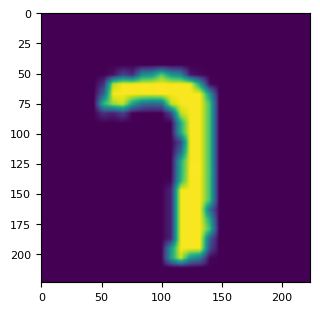

In [6]:
sample = next(iter(trainDataLoader))
pst(sample[0])    # image
pst(sample[1])    # label
img = sample[0][0]# image[0]

plt.imshow(img.permute(1, 2, 0))
plt.show()

## Model Define

In [7]:
class Wrap_10(L.LightningModule):
    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = F.cross_entropy(y_pred, y)
        acc = FM.accuracy(y_pred, y, task="multiclass",num_classes=10)
        metrics={'loss':loss, 'acc':acc}
        self.log_dict(metrics,prog_bar=True,on_step=False,on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = F.cross_entropy(y_pred, y)
        acc = FM.accuracy(y_pred, y, task="multiclass",num_classes=10)
        metrics={'val_loss':loss, 'val_acc':acc}
        self.log_dict(metrics,prog_bar=True,on_step=False,on_epoch=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

In [8]:
## 한쪽 path만 구현해 보자

class AlexNet_like(Wrap_10):
    def __init__(self):
        super(AlexNet_like, self).__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(1, 48, (11,11), stride=4, padding=2),
            nn.ReLU(),
            nn.MaxPool2d((3,3), stride=2),

            nn.Conv2d(48, 128, (5,5), padding=2),
            nn.ReLU(),
            nn.MaxPool2d((3,3), stride=2),

            nn.Conv2d(128, 192, (3,3), padding=1),
            nn.ReLU(),
            nn.Conv2d(192, 192, (3,3), padding=1),
            nn.ReLU(),
            nn.Conv2d(192, 128, (3,3), padding=1),
            nn.ReLU(),
            nn.MaxPool2d((3,3), stride=2),

            nn.Flatten(),
            nn.Linear(128 * 6 * 6, 2048),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(2048, 2048),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(2048, 10),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.layers(x)
        return x

model = AlexNet_like()
summary(model, input_size=(batch_size, 1, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
AlexNet_like                             [10, 10]                  --
├─Sequential: 1-1                        [10, 10]                  --
│    └─Conv2d: 2-1                       [10, 48, 55, 55]          5,856
│    └─ReLU: 2-2                         [10, 48, 55, 55]          --
│    └─MaxPool2d: 2-3                    [10, 48, 27, 27]          --
│    └─Conv2d: 2-4                       [10, 128, 27, 27]         153,728
│    └─ReLU: 2-5                         [10, 128, 27, 27]         --
│    └─MaxPool2d: 2-6                    [10, 128, 13, 13]         --
│    └─Conv2d: 2-7                       [10, 192, 13, 13]         221,376
│    └─ReLU: 2-8                         [10, 192, 13, 13]         --
│    └─Conv2d: 2-9                       [10, 192, 13, 13]         331,968
│    └─ReLU: 2-10                        [10, 192, 13, 13]         --
│    └─Conv2d: 2-11                      [10, 128, 13, 13]         

In [ ]:
%%time
model = AlexNet_like()
epochs = 10
name="AlexNet"
logger = L.pytorch.loggers.CSVLogger("logs", name=name)
trainer = L.Trainer(max_epochs=epochs, logger=logger,enable_model_summary=False,
                    limit_train_batches=0.5, limit_val_batches=0.5 )  #####
trainer.fit(model, trainDataLoader, val_dataloaders=valDataLoader)
# Wall time: 54.6 s

In [ ]:
v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')

In [ ]:
h1 = history.drop('step', axis=1).groupby('epoch').last()
max_ = h1['val_acc'].max()

plt.figure(figsize=(10,3))
title = name
plt.subplot(121)
plt.title(f"{title}\nMax Val_Acc:{max_:.4f}")
plt.plot(h1['acc'],'--', label='acc')
plt.plot(h1['val_acc'], label='val_acc')
#plt.ylim(0.7, 1)
plt.legend()
plt.grid()

plt.subplot(122)
plt.title("Loss")
plt.plot(h1['loss'],'--', label='loss')
plt.plot(h1['val_loss'], label='val_loss')
plt.semilogy()
plt.legend()
plt.grid()
plt.show()

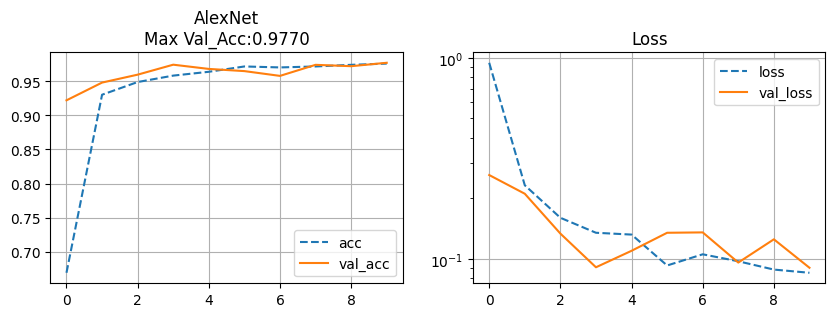

# VGG-11 모델 만들기

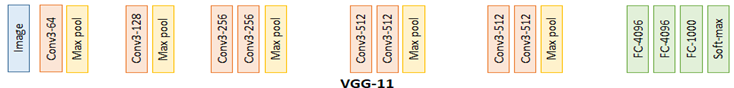

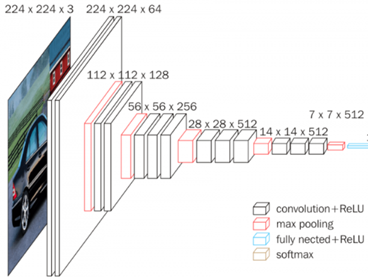

In [9]:
class VGG_11(Wrap_10):
    def __init__(self):
        super(VGG_11, self).__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(1, 64, (3,3), stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d((2,2), stride=2),

            nn.Conv2d(64, 128, (3,3), stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d((2,2), stride=2),

            nn.Conv2d(128, 256, (3,3), stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, (3,3), stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d((2,2), stride=2),

            nn.Conv2d(256, 512, (3,3), stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, (3,3), stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d((2,2), stride=2),

            nn.Conv2d(512, 512, (3,3), stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, (3,3), stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d((2,2), stride=2),

            nn.Flatten(),
            nn.Dropout(0.1),
            nn.Linear(512*7*7, 10),

            # nn.Linear(512*7*7, 4096),
            # nn.Linear(4096, 4096),
            # nn.Linear(4096, 1000),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.layers(x)
        return x

model = VGG_11()
summary(model, input_size=(batch_size, 1, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
VGG_11                                   [10, 10]                  --
├─Sequential: 1-1                        [10, 10]                  --
│    └─Conv2d: 2-1                       [10, 64, 224, 224]        640
│    └─ReLU: 2-2                         [10, 64, 224, 224]        --
│    └─MaxPool2d: 2-3                    [10, 64, 112, 112]        --
│    └─Conv2d: 2-4                       [10, 128, 112, 112]       73,856
│    └─ReLU: 2-5                         [10, 128, 112, 112]       --
│    └─MaxPool2d: 2-6                    [10, 128, 56, 56]         --
│    └─Conv2d: 2-7                       [10, 256, 56, 56]         295,168
│    └─ReLU: 2-8                         [10, 256, 56, 56]         --
│    └─Conv2d: 2-9                       [10, 256, 56, 56]         590,080
│    └─ReLU: 2-10                        [10, 256, 56, 56]         --
│    └─MaxPool2d: 2-11                   [10, 256, 28, 28]         --


In [ ]:
%%time
model = VGG_11()
epochs = 10
name="VGG-11"
logger = L.pytorch.loggers.CSVLogger("logs", name=name)
trainer = L.Trainer(max_epochs=epochs, logger=logger,enable_model_summary=False,
                    limit_train_batches=0.3, limit_val_batches=0.3 )  #####
trainer.fit(model, trainDataLoader, val_dataloaders=valDataLoader)
# Wall time: 2min 40s

In [ ]:
v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')

In [ ]:
h1 = history.drop('step', axis=1).groupby('epoch').last()
max_ = h1['val_acc'].max()

plt.figure(figsize=(10,3))
title = name
plt.subplot(121)
plt.title(f"{title}\nMax Val_Acc:{max_:.4f}")
plt.plot(h1['acc'],'--', label='acc')
plt.plot(h1['val_acc'], label='val_acc')
#plt.ylim(0.7, 1)
plt.legend()
plt.grid()

plt.subplot(122)
plt.title("Loss")
plt.plot(h1['loss'],'--', label='loss')
plt.plot(h1['val_loss'], label='val_loss')
plt.semilogy()
plt.legend()
plt.grid()
plt.show()

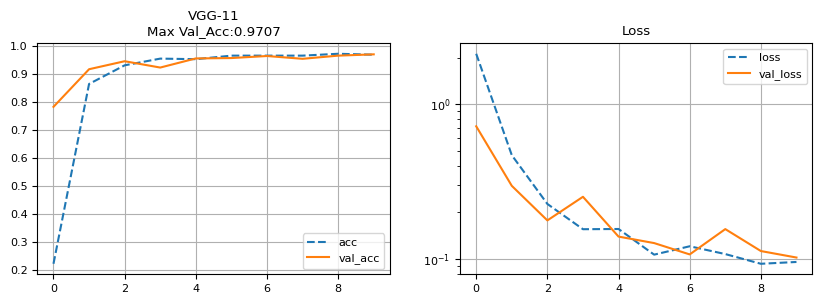

**종종 학습에 실패하는 경우도 발생**

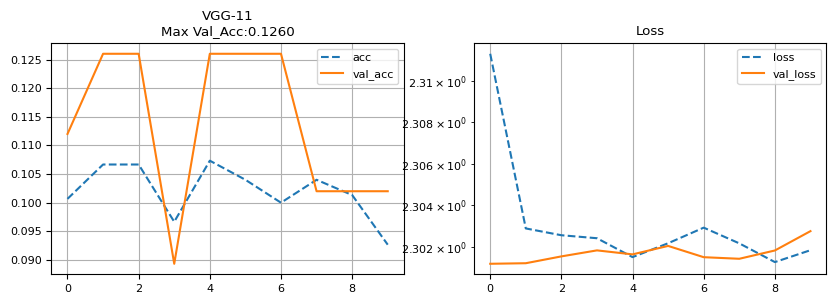

# VGG-16 모델을 만들어 보자  
### VGG_11 code에서 수정해서 만들어 보자

In [ ]:
class VGG_11(Wrap_10):
    def __init__(self):
        super(VGG_11, self).__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(1, 64, (3,3), stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d((2,2), stride=2),

            nn.Conv2d(64, 128, (3,3), stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d((2,2), stride=2),

            nn.Conv2d(128, 256, (3,3), stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, (3,3), stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d((2,2), stride=2),

            nn.Conv2d(256, 512, (3,3), stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, (3,3), stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d((2,2), stride=2),

            nn.Conv2d(512, 512, (3,3), stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, (3,3), stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d((2,2), stride=2),

            nn.Flatten(),
            nn.Dropout(0.1),
            nn.Linear(512*7*7, 10),
            # nn.Linear(512*7*7, 4096),
            # nn.Linear(4096, 4096),
            # nn.Linear(4096, 1000),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.layers(x)
        return x

model = VGG_11()
summary(model, input_size=(batch_size, 1, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
VGG_11                                   [10, 10]                  --
├─Sequential: 1-1                        [10, 10]                  --
│    └─Conv2d: 2-1                       [10, 64, 224, 224]        640
│    └─ReLU: 2-2                         [10, 64, 224, 224]        --
│    └─MaxPool2d: 2-3                    [10, 64, 112, 112]        --
│    └─Conv2d: 2-4                       [10, 128, 112, 112]       73,856
│    └─ReLU: 2-5                         [10, 128, 112, 112]       --
│    └─MaxPool2d: 2-6                    [10, 128, 56, 56]         --
│    └─Conv2d: 2-7                       [10, 256, 56, 56]         295,168
│    └─ReLU: 2-8                         [10, 256, 56, 56]         --
│    └─Conv2d: 2-9                       [10, 256, 56, 56]         590,080
│    └─ReLU: 2-10                        [10, 256, 56, 56]         --
│    └─MaxPool2d: 2-11                   [10, 256, 28, 28]         --


In [ ]:
%%time
model = VGG_11()
epochs = 10
name="VGG-11"
logger = L.pytorch.loggers.CSVLogger("logs", name=name)
trainer = L.Trainer(max_epochs=epochs, logger=logger,enable_model_summary=False,
                    limit_train_batches=0.3, limit_val_batches=0.3 )  #####
trainer.fit(model, trainDataLoader, val_dataloaders=valDataLoader)
# Wall time: 2min 42s

In [ ]:
v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')

In [ ]:
h1 = history.drop('step', axis=1).groupby('epoch').last()
max_ = h1['val_acc'].max()

plt.figure(figsize=(10,3))
title = name
plt.subplot(121)
plt.title(f"{title}\nMax Val_Acc:{max_:.4f}")
plt.plot(h1['acc'],'--', label='acc')
plt.plot(h1['val_acc'], label='val_acc')
#plt.ylim(0.7, 1)
plt.legend()
plt.grid()

plt.subplot(122)
plt.title("Loss")
plt.plot(h1['loss'],'--', label='loss')
plt.plot(h1['val_loss'], label='val_loss')
plt.semilogy()
plt.legend()
plt.grid()
plt.show()